<a href="https://colab.research.google.com/github/Zainab-Binte-Khalid/urdu-ocr-codesaviours-si26-zainab/blob/main/SI26_Week1_Zainab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 Research Task

## 1. What is OCR (Optical Character Recognition)?

Optical Character Recognition (OCR) is a technology that converts text from images, scanned documents, or photographs into editable and searchable digital text. It helps computers recognize printed or handwritten characters without typing them manually. OCR is widely used to digitize books, forms, receipts, and historical documents.

## 2. Why is Urdu OCR harder than English OCR?

Urdu OCR is more difficult than English OCR because Urdu is written in a connected script, where the shape of letters changes depending on their position in a word. Urdu also contains many dots and special marks that can be difficult for a computer to identify accurately. Different fonts, handwriting styles, and image quality make Urdu OCR even more challenging.

## 3. What are two real-world situations where Urdu OCR would be useful?

One use of Urdu OCR is converting printed Urdu books, newspapers, and old documents into editable digital text for preservation and searching. Another use is reading information from government forms, educational documents, or business records written in Urdu so the information can be stored and processed electronically.


In [85]:
!pip install Pillow arabic-reshaper python-bidi

In [86]:
import requests

# Trick: old user-agent forces Google to serve .ttf instead of .woff2
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/41.0.2228.0 Safari/537.36'
}

css_url = 'https://fonts.googleapis.com/css2?family=Noto+Nastaliq+Urdu&display=swap'
css_response = requests.get(css_url, headers=headers)
print(css_response.text)  # this will show a url(...) line pointing to the actual font file

/* arabic */
@font-face {
  font-family: 'Noto Nastaliq Urdu';
  font-style: normal;
  font-weight: 400;
  font-display: swap;
  src: url(https://fonts.gstatic.com/s/notonastaliqurdu/v23/LhWNMUPbN-oZdNFcBy1-DJYsEoTq5pudQ9L940pGPkB3Qt_-PK-V3N_8.woff) format('woff');
  unicode-range: U+0600-06FF, U+0750-077F, U+0870-088E, U+0890-0891, U+0897-08E1, U+08E3-08FF, U+200C-200E, U+2010-2011, U+204F, U+2E41, U+FB50-FDFF, U+FE70-FE74, U+FE76-FEFC, U+102E0-102FB, U+10E60-10E7E, U+10EC2-10EC4, U+10EFC-10EFF, U+1EE00-1EE03, U+1EE05-1EE1F, U+1EE21-1EE22, U+1EE24, U+1EE27, U+1EE29-1EE32, U+1EE34-1EE37, U+1EE39, U+1EE3B, U+1EE42, U+1EE47, U+1EE49, U+1EE4B, U+1EE4D-1EE4F, U+1EE51-1EE52, U+1EE54, U+1EE57, U+1EE59, U+1EE5B, U+1EE5D, U+1EE5F, U+1EE61-1EE62, U+1EE64, U+1EE67-1EE6A, U+1EE6C-1EE72, U+1EE74-1EE77, U+1EE79-1EE7C, U+1EE7E, U+1EE80-1EE89, U+1EE8B-1EE9B, U+1EEA1-1EEA3, U+1EEA5-1EEA9, U+1EEAB-1EEBB, U+1EEF0-1EEF1;
}
/* latin-ext */
@font-face {
  font-family: 'Noto Nastaliq Urdu';
  font-style: no

In [87]:
import requests

# Download the woff file (Arabic subset — covers Urdu characters)
woff_url = 'https://fonts.gstatic.com/s/notonastaliqurdu/v23/LhWNMUPbN-oZdNFcBy1-DJYsEoTq5pudQ9L940pGPkB3Qt_-PK-V3N_8.woff'
r = requests.get(woff_url)
with open('NotoNastaliqUrdu.woff', 'wb') as f:
    f.write(r.content)

print('Downloaded woff file:', len(r.content), 'bytes')

Downloaded woff file: 210316 bytes


In [88]:
!pip install fonttools

from fontTools.ttLib import TTFont

font = TTFont('NotoNastaliqUrdu.woff')
font.flavor = None  # strip the woff wrapper, keep the raw outlines
font.save('NotoNastaliqUrdu.ttf')

print('Converted to NotoNastaliqUrdu.ttf')

Converted to NotoNastaliqUrdu.ttf


In [89]:
from PIL import ImageFont
test_font = ImageFont.truetype('NotoNastaliqUrdu.ttf', 32)
print('Font loaded successfully!')

Font loaded successfully!


Generate syntehtic image

In [90]:
from PIL import Image, ImageDraw, ImageFont
import arabic_reshaper
from bidi.algorithm import get_display
import os
import csv

# 24 Urdu sentences — each becomes one labeled image
urdu_texts = [
    "پاکستان زندہ باد",
    "آج کا موسم خوشگوار ہے",
    "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "محنت کامیابی کی کنجی ہے",
    "پانی زندگی کے لیے ضروری ہے",
    "دوستی ایک انمول رشتہ ہے",
    "کتابیں علم کا خزانہ ہیں",
    "صحت ہزار نعمت ہے",
    "وقت کی قدر کرنی چاہیے",
    "محبت سب سے بڑی طاقت ہے",
    "سچائی ہمیشہ جیتتی ہے",
    "امن ہر انسان کی خواہش ہے",
    "خوشی بانٹنے سے بڑھتی ہے",
    "علم انسان کو روشنی دیتا ہے",
    "قدرت کا حسن بے مثال ہے",
    "اردو ایک شیریں زبان ہے",
    "بچے قوم کا مستقبل ہیں",
    "محنت سے ہر خواب پورا ہوتا ہے",
    "شکر گزاری خوشی کی کنجی ہے",
    "لاہور تاریخی شہر ہے",
    "کتاب دوست بہترین ساتھی ہے",
    "ہمت مرداں مدد خدا",
    "اچھے اخلاق سب سے بڑی دولت ہیں",
]

# Create output folder
os.makedirs('synthetic', exist_ok=True)

# Load the Urdu font
font = ImageFont.truetype("NotoNastaliqUrdu.ttf", 32)

# Generate images + collect labels
labels = []
for i, text in enumerate(urdu_texts):
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)

    img = Image.new('RGB', (500, 90), color='white')
    draw = ImageDraw.Draw(img)
    draw.text((20, 25), bidi_text, fill='black', font=font)

    filename = f'syn_{i+1:03d}.png'
    img.save(f'synthetic/{filename}')
    labels.append({'image': filename, 'text': text})
    print(f'Generated: {filename} -- {text}')

# Save labels.csv
with open('synthetic/labels.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['image', 'text'])
    writer.writeheader()
    writer.writerows(labels)

print(f'\nDone! {len(labels)} synthetic images + labels.csv saved in synthetic/ folder')

Generated: syn_001.png -- پاکستان زندہ باد
Generated: syn_002.png -- آج کا موسم خوشگوار ہے
Generated: syn_003.png -- تعلیم ہر انسان کا حق ہے
Generated: syn_004.png -- کراچی پاکستان کا سب سے بڑا شہر ہے
Generated: syn_005.png -- محنت کامیابی کی کنجی ہے
Generated: syn_006.png -- پانی زندگی کے لیے ضروری ہے
Generated: syn_007.png -- دوستی ایک انمول رشتہ ہے
Generated: syn_008.png -- کتابیں علم کا خزانہ ہیں
Generated: syn_009.png -- صحت ہزار نعمت ہے
Generated: syn_010.png -- وقت کی قدر کرنی چاہیے
Generated: syn_011.png -- محبت سب سے بڑی طاقت ہے
Generated: syn_012.png -- سچائی ہمیشہ جیتتی ہے
Generated: syn_013.png -- امن ہر انسان کی خواہش ہے
Generated: syn_014.png -- خوشی بانٹنے سے بڑھتی ہے
Generated: syn_015.png -- علم انسان کو روشنی دیتا ہے
Generated: syn_016.png -- قدرت کا حسن بے مثال ہے
Generated: syn_017.png -- اردو ایک شیریں زبان ہے
Generated: syn_018.png -- بچے قوم کا مستقبل ہیں
Generated: syn_019.png -- محنت سے ہر خواب پورا ہوتا ہے
Generated: syn_020.png -- شکر گزاری خوشی کی کنجی ہے
Ge

In [91]:
from google.colab import drive
drive.mount('/content/drive')

import os

base = '/content/drive/MyDrive/archive'

for folder in ['newspaper', 'Line_data_newforms']:
    path = os.path.join(base, folder)
    print(f'--- {folder} ---')
    items = os.listdir(path)
    print(f'Total items: {len(items)}')
    print(items[:10])
    print()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- newspaper ---
Total items: 12
['dawn06 (1).png', 'BBC06 (1).png', 'BBC02 (1).png', 'dawn04 (1).png', 'BBC05 (1).png', 'dawn01 (1).png', 'dawn03 (1).png', 'BBC03 (1).png', 'BBC01 (1).png', 'BBC04 (1).png']

--- Line_data_newforms ---
Total items: 2
['New_data_labels.csv', 'Images']



In [92]:
import os
import pandas as pd

base = '/content/drive/MyDrive/archive/Line_data_newforms'

# Check the Images subfolder
images_path = os.path.join(base, 'Images')
image_files = os.listdir(images_path)
print(f'Total images in Images/: {len(image_files)}')
print(image_files[:10])
print()

# Check the CSV structure
csv_path = os.path.join(base, 'New_data_labels.csv')
df = pd.read_csv(csv_path)
print('CSV columns:', df.columns.tolist())
print('CSV shape:', df.shape)
print()
print(df.head())

Total images in Images/: 78
['textbox_17_line_2_.png', 'textbox_19_line_1_.png', 'textbox_14_line_2_.png', 'textbox_10_line_1_.png', 'textbox_27_line_2_.png', 'textbox_16_line_2_.png', 'textbox_1_line_1_.png', 'textbox_15_line_3_.png', 'textbox_24_line_1_.png', 'textbox_14_line_1_.png']

CSV columns: ['Unnamed: 0', 'Labels', 'path']
CSV shape: (78, 3)

   Unnamed: 0                                        Labels  \
0           0         ہوٹل کا عملہ نہایت دوستانہ ہے عملہ نے   
1           1     میری بہت مدد کی میں یہاں ضرور واپس آؤں گا   
2           2          ہوٹل کی فضا خوشگوار ہے ہوٹل کا ماحول   
3           3            خوشگوار ہے ہوٹل کا عملہ دوستانہ ہے   
4           4  ہوٹل کا سٹاف اور عملہ نہایت اچھا اور دوستانہ   

                    path  
0  textbox_1_line_1_.png  
1  textbox_1_line_2_.png  
2  textbox_2_line_1_.png  
3  textbox_2_line_2_.png  
4  textbox_3_line_1_.png  


Labeled data

In [93]:
import os
import shutil
import csv
import pandas as pd

# Final unified dataset folder
final_folder = 'urdu_ocr_dataset'
os.makedirs(f'{final_folder}/images', exist_ok=True)

master_labels = []
counter = 1

# ---- 1. Synthetic images (24, already labeled) ----
for i, text in enumerate(urdu_texts):
    src = f'synthetic/syn_{i+1:03d}.png'
    new_name = f'img_{counter:03d}.png'
    shutil.copy(src, f'{final_folder}/images/{new_name}')
    master_labels.append({'image': new_name, 'text': text, 'source': 'synthetic'})
    counter += 1

# ---- 2. Line_data_newforms (78, labeled via CSV) ----
base2 = '/content/drive/MyDrive/archive/Line_data_newforms'
df2 = pd.read_csv(os.path.join(base2, 'New_data_labels.csv'))

for _, row in df2.iterrows():
    src = os.path.join(base2, 'Images', row['path'])
    new_name = f'img_{counter:03d}.png'
    shutil.copy(src, f'{final_folder}/images/{new_name}')
    master_labels.append({'image': new_name, 'text': row['Labels'], 'source': 'line_data_dataset'})
    counter += 1

# ---- 3. Newspaper screenshots (12, no labels yet — blank for now) ----
base3 = '/content/drive/MyDrive/archive/newspaper'
newspaper_filenames_sorted = sorted(os.listdir(base3))
print('Newspaper files in the order they will be added:')
print(newspaper_filenames_sorted)

for fname in newspaper_filenames_sorted:
    src = os.path.join(base3, fname)
    new_name = f'img_{counter:03d}.png'
    shutil.copy(src, f'{final_folder}/images/{new_name}')
    master_labels.append({'image': new_name, 'text': '', 'source': 'newspaper_screenshot'})
    counter += 1

# Write master CSV
with open(f'{final_folder}/labels.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['image', 'text', 'source'])
    writer.writeheader()
    writer.writerows(master_labels)

print(f'\nDone! {counter-1} images consolidated into {final_folder}/')
print(f'Breakdown: 24 synthetic + 78 line_data + 12 newspaper = {counter-1}')

Newspaper files in the order they will be added:
['BBC01 (1).png', 'BBC02 (1).png', 'BBC03 (1).png', 'BBC04 (1).png', 'BBC05 (1).png', 'BBC06 (1).png', 'dawn01 (1).png', 'dawn02 (1).png', 'dawn03 (1).png', 'dawn04 (1).png', 'dawn05 (1).png', 'dawn06 (1).png']

Done! 114 images consolidated into urdu_ocr_dataset/
Breakdown: 24 synthetic + 78 line_data + 12 newspaper = 114


In [94]:
newspaper_filenames_sorted = sorted([
    'BBC01 (1).png', 'BBC02 (1).png', 'BBC03 (1).png', 'BBC04 (1).png',
    'BBC05 (1).png', 'BBC06 (1).png', 'dawn01 (1).png', 'dawn03 (1).png',
    'dawn04 (1).png', 'dawn06 (1).png'
])
print(newspaper_filenames_sorted)

['BBC01 (1).png', 'BBC02 (1).png', 'BBC03 (1).png', 'BBC04 (1).png', 'BBC05 (1).png', 'BBC06 (1).png', 'dawn01 (1).png', 'dawn03 (1).png', 'dawn04 (1).png', 'dawn06 (1).png']


Text write for newspaper images

In [95]:
newspaper_texts = [
    """وینزویلا میں پانچ روز قبل یکے بعد دیگرے آنے والے شدید زلزلوں میں مرنے والوں کی تعداد 1400 سے بڑھ گئی ہے وہیں ملبے تلے دبے افراد کے زندہ بچنے کی امید دم توڑنے لگی ہے اور ہلاک شدگان کی تعداد میں بڑے اضافے کا خدشہ ظاہر کیا جا رہا ہے۔

بدھ کو ملک کے شمالی حصے میں آنے والے ان زلزلوں سے دارالحکومت کراکس سمیت بڑے علاقے میں عمارتیں تباہ ہوئیں جن کے ملبے تلے دبے افراد کی تلاش کا عمل جاری ہے۔ اتوار کو ملبے سے 33 افراد کو زندہ نکالا گیا۔

ایک برطانوی ریسکیو اہلکار کے مطابق ایسے حالات میں متاثرین کے زندہ نکلنے کی مدت 96 گھنٹے تک سمجھی جاتی ہے جو اتوار کی شام ختم ہو گئی اور اب امدادی کارکنوں کو ’معجزات‘ کی امید ہے۔

تلاش اور بچاؤ کے عمل میں حصہ لینے کے لیے غیر ملکی ٹیموں کی وینزویلا آمد کا سلسلہ بھی جاری ہے۔ ایک اعلیٰ سرکاری عہدیدار نے بتایا کہ سینکڑوں بین الاقوامی امدادی کارکن وینزویلا پہنچ چکے ہیں جبکہ مزید کی آمد متوقع ہے تاہم ملبہ اٹھانے کے لیے درکار مشینری کی قلت ایک بڑا مسئلہ بن کر سامنے آئی ہے۔""",

    """تلاش اور بچاؤ کے عمل میں حصہ لینے کے لیے غیر ملکی ٹیموں کی وینزویلا آمد کا سلسلہ بھی جاری ہے۔ ایک اعلیٰ سرکاری عہدیدار نے بتایا کہ سینکڑوں بین الاقوامی امدادی کارکن وینزویلا پہنچ چکے ہیں جبکہ مزید کی آمد متوقع ہے تاہم ملبہ اٹھانے کے لیے درکار مشینری کی قلت ایک بڑا مسئلہ بن کر سامنے آئی ہے۔

حکام کا کہنا ہے کہ اس قدرتی آفت کے نتیجے میں چار ہزار سے زیادہ افراد زخمی بھی ہوئے ہیں۔ وینزویلا میں حکومت کی جانب سے تاحال لاپتہ افراد کی تعداد کے بارے میں معلومات فراہم نہیں کی گئیں تاہم زلزلے کے بعد لاپتہ ہونے والے افراد کے بارے میں معلومات جمع کرنے والی ایک نجی ویب سائٹ کے مطابق 46 ہزار افراد ایسے ہیں جن کا زلزلے کے بعد اپنے اہلخانہ سے رابطہ نہیں ہوا ہے۔""",

    """کراکس میں موجود بی بی سی کی یوگیتا لمائے کے مطابق ہسپتالوں کی بیرونی دیواریں لاپتہ افراد کی تصاویر سے بھرتی جا رہی ہیں۔

زلزلوں کے فوراً بعد امریکی ارضیاتی سروے نے زلزلے کی شدت اور متاثرہ علاقے کی آبادی کے حساب سے اندازہ لگایا تھا کہ مرنے والوں کی تعداد دس ہزار سے ایک لاکھ کے درمیان ہو سکتی ہے۔

امریکی ارضیاتی سروے (یو ایس جی ایس) کے مطابق بدھ کے روز آنے والے پہلے زلزلے کی شدت 7.2 تھی اور اس کے چند ہی سیکنڈ بعد اس سے بھی زیادہ طاقتور 7.5 شدت کا دوسرا زلزلہ آیا۔""",

    """لاگوائیرا میں ناتاشا دیاز نے بی بی سی کو بتایا کہ ان کی دو بیٹیاں، جن کی عمریں 22 اور 23 برس ہیں، ایک منہدم شاپنگ سینٹر کے ملبے تلے دبی ہوئی ہیں۔ وہ دونوں وہاں کام کرتی تھیں۔

انہوں نے بتایا کہ ’وہ اپنے دوستوں کے ساتھ تھیں۔ میں صرف یہ چاہتی ہوں کہ وہ مل جائیں۔ مجھے یقین اور امید ہے کہ وہ وہیں ہیں۔‘

’میں صرف انہیں واپس اپنے پاس دیکھنا چاہتی ہوں۔ وہ ہی میرا سب کچھ ہیں۔‘

قائم مقام صدر ڈیلسی روڈریگز نے جمعے کو ایک ٹی وی بریفنگ میں کہا کہ درجنوں افراد کو زندہ نکال لیا گیا، جو ’ہمارے لیے باعثِ خوشی ہے کہ وہ اپنے خاندان اور پیاروں سے دوبارہ مل سکے۔‘

انہوں نے مزید بتایا کہ ابتدائی زلزلوں کے بعد سے 214 آفٹر شاکس آ چکے ہیں۔""",

    """امدادی کارروائیوں میں مدد کے لیے کئی ممالک نے تعاون کی پیشکش کی ہے، جن میں امریکہ کی جانب سے 15 کروڑ ڈالر کی امداد کا اعلان بھی شامل ہے۔

ہورخے روڈریگز کے مطابق 250 عمارتیں مکمل طور پر تباہ ہو گئی ہیں یا انھیں شدید نقصان پہنچا۔ ان میں سے بیشتر عمارتیں لاگوائیرا میں واقع تھیں جہاں بی بی سی نے ایک 10 منزلہ ہوٹل کے ملبے میں تبدیل ہونے کی ویڈیو کی تصدیق کی۔

وزیر داخلہ دیوسدادو کابیلو کا کہنا ہے کہ دارالحکومت کراکس میں بھی کئی عمارتیں منہدم ہوئی ہیں جبکہ تروخیلو، یاراکوئے، کارابوبو، اراگوا اور میرانڈا کی ریاستیں بھی زلزلے سے متاثر ہوئی ہیں۔""",

    """اس وقت ایران کا کوئی اعلیٰ سطحی نمائندہ دوحہ میں موجود نہیں: قطر

قطر کا کہنا ہے کہ ڈونلڈ ٹرمپ کے اعلیٰ سطحی نمائندے دوحہ میں موجود ہیں لیکن ایران اور امریکہ کے درمیان کسی اعلیٰ سطح کی ملاقات کی منصوبہ بندی نہیں کی گئی ہے۔

قطر کی وزارتِ خارجہ کے ترجمان ماجد انصاری نے کہا کہ سٹیو وٹکف اور جیرڈ کشنر ثالثوں سے ملاقاتات اور ’علاقائی امور‘ پر بات چیت کے لیے دوحہ آئے ہیں۔

انہوں نے کہا کہ یہ بات چیت ایران اور دیگر موضوعات جیسے لبنان کی صورتحال کے بارے میں ہوگی۔

انصاری کے مطابق، فی الحال ایران کا کوئی اعلیٰ سطحی نمائندہ قطر میں موجود نہیں ہے اور انہوں نے زور دے کر کہا کہ ڈونلڈ ٹرمپ کے نمائندے ایران کے ساتھ مذاکرات کے لیے دوحہ نہیں آئے ہیں: ’جہاں تک مجھے علم ہے، آنے والے دنوں میں دونوں فریقوں کے درمیان کسی براہِ راست اجلاس کی منصوبہ بندی نہیں کی گئی ہے۔‘""",

    """لاہور: قانون نافذ کرنے والے ادارے تقریباً تین ماہ گزرنے کے باوجود تحریک لبیک پاکستان کے سربراہ سعد حسین رضوی اور ان کے بھائی انس رضوی کے ٹھکانے کے بارے میں لاعلم ہیں۔""",

    """ڈان اخبار میں شائع خبر کے مطابق یہ معاملہ چند روز قبل اس وقت دوبارہ سامنے آیا جب کالعدم مذہبی تنظیم سے منسوب ایک مبینہ بیان سوشل میڈیا پر گردش کرنے لگا، جس میں دعویٰ کیا گیا کہ دونوں بھائی ریاستی اداروں کی تحویل میں ہیں۔""",

    """تاہم قانون نافذ کرنے والے سینئر حکام اپنے پہلے مؤقف پر قائم ہیں اور ان کا کہنا ہے کہ دونوں بھائی آزاد جموں و کشمیر میں کہیں چھپے ہوئے ہیں۔ ان کے مطابق رضوی برادران اس دن فرار ہوئے جب پنجاب پولیس نے مریدکے میں جی ٹی روڈ پر قائم ٹی ایل پی کے احتجاجی کیمپ کو ختم کرنے کے لیے علی الصبح آپریشن کیا تھا۔""",

    """ایک سینئر افسر نے ڈان سے بات کرتے ہوئے کہا کہ وہ یقین سے کہہ سکتے ہیں کہ سعد اور انس کسی بھی سیکیورٹی ادارے کی تحویل میں نہیں اور تاحال آزاد کشمیر میں موجود ہیں۔""",

    """ان کے بقول غالب امکان ہے کہ وہ کالعدم تنظیم کے کسی وفادار کارکن کے پاس پہاڑی علاقوں میں پناہ لیے ہوئے ہیں۔ انہوں نے مبینہ ٹی ایل پی بیان کو جھوٹا، مضحکہ خیز اور خود ساختہ قرار دیا۔""",

    """امریکی صدر ڈونلڈ ٹرمپ نے کہا ہے کہ ایران کی قیادت نے فوجی کارروائی کی دھمکیوں کے بعد مذاکرات کے لیے رابطہ کیا ہے۔

ایئر فورس ون میں اتوار کو صحافیوں سے گفتگو کرتے ہوئے ڈونلڈ ٹرمپ نے بتایا کہ ایران کے رہنماؤں نے گزشتہ روز فون کیا اور ایک ملاقات طے کی جا رہی ہے۔ ان کے مطابق ایران مذاکرات چاہتا ہے تاہم انہوں نے خبردار کیا کہ ممکن ہے ملاقات سے پہلے ہی ہمیں کارروائی کرنا پڑے۔"""
]

import pandas as pd

df = pd.read_csv('urdu_ocr_dataset/labels.csv')

newspaper_mask = df['source'] == 'newspaper_screenshot'
newspaper_indices = df[newspaper_mask].index.tolist()

for idx, text in zip(newspaper_indices, newspaper_texts):
    df.loc[idx, 'text'] = text

df.to_csv('urdu_ocr_dataset/labels.csv', index=False)

print("Newspaper labels updated with real text!")
print(df[df['source'] == 'newspaper_screenshot'][['image', 'text']])

Newspaper labels updated with real text!
           image                                               text
102  img_103.png  وینزویلا میں پانچ روز قبل یکے بعد دیگرے آنے وا...
103  img_104.png  تلاش اور بچاؤ کے عمل میں حصہ لینے کے لیے غیر م...
104  img_105.png  کراکس میں موجود بی بی سی کی یوگیتا لمائے کے مط...
105  img_106.png  لاگوائیرا میں ناتاشا دیاز نے بی بی سی کو بتایا...
106  img_107.png  امدادی کارروائیوں میں مدد کے لیے کئی ممالک نے ...
107  img_108.png  اس وقت ایران کا کوئی اعلیٰ سطحی نمائندہ دوحہ م...
108  img_109.png  لاہور: قانون نافذ کرنے والے ادارے تقریباً تین ...
109  img_110.png  ڈان اخبار میں شائع خبر کے مطابق یہ معاملہ چند ...
110  img_111.png  تاہم قانون نافذ کرنے والے سینئر حکام اپنے پہلے...
111  img_112.png  ایک سینئر افسر نے ڈان سے بات کرتے ہوئے کہا کہ ...
112  img_113.png  ان کے بقول غالب امکان ہے کہ وہ کالعدم تنظیم کے...
113  img_114.png  امریکی صدر ڈونلڈ ٹرمپ نے کہا ہے کہ ایران کی قی...


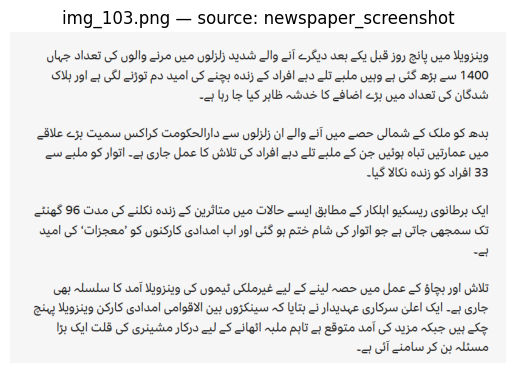

وینزویلا میں پانچ روز قبل یکے بعد دیگرے آنے والے شدید زلزلوں میں مرنے والوں کی تعداد 1400 سے بڑھ گئی ہے وہیں ملبے تلے دبے افراد کے زندہ بچنے کی امید دم توڑنے لگی ہے اور ہلاک شدگان کی تعداد میں بڑے اضافے کا خدشہ ظاہر کیا جا رہا ہے۔

بدھ کو ملک کے شمالی حصے میں آنے والے ان زلزلوں سے دارالحکومت کراکس سمیت بڑے علاقے میں عمارتیں تباہ ہوئیں جن کے ملبے تلے دبے افراد کی تلاش کا عمل جاری ہے۔ اتوار کو ملبے سے 33 افراد کو زندہ نکالا گیا۔

ایک برطانوی ریسکیو اہلکار کے مطابق ایسے حالات میں متاثرین کے زندہ نکلنے کی مدت 96 گھنٹے تک سمجھی جاتی ہے جو اتوار کی شام ختم ہو گئی اور اب امدادی کارکنوں کو ’معجزات‘ کی امید ہے۔

تلاش اور بچاؤ کے عمل میں حصہ لینے کے لیے غیر ملکی ٹیموں کی وینزویلا آمد کا سلسلہ بھی جاری ہے۔ ایک اعلیٰ سرکاری عہدیدار نے بتایا کہ سینکڑوں بین الاقوامی امدادی کارکن وینزویلا پہنچ چکے ہیں جبکہ مزید کی آمد متوقع ہے تاہم ملبہ اٹھانے کے لیے درکار مشینری کی قلت ایک بڑا مسئلہ بن کر سامنے آئی ہے۔


In [96]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

df = pd.read_csv('urdu_ocr_dataset/labels.csv')
row = df[df['image'] == 'img_103.png'].iloc[0]

img = Image.open(f'urdu_ocr_dataset/images/{row.image}')
plt.imshow(img)
plt.title(f"{row.image} — source: {row.source}")
plt.axis('off')
plt.show()

print(row.text)

Synthetic image show empty

In [1]:
from fontTools.ttLib import TTFont

font = TTFont('NotoNastaliqUrdu.ttf')
cmap = font.getBestCmap()
print('Total glyphs mapped:', len(cmap))

# Check if a specific Urdu character exists (0627 = Arabic letter Alef)
test_char = 0x0627
print('Contains Alef (ا)?', test_char in cmap)

FileNotFoundError: [Errno 2] No such file or directory: 'NotoNastaliqUrdu.ttf'

In [2]:
import requests
from fontTools.ttLib import TTFont

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/41.0.2228.0 Safari/537.36'
}

woff_url = 'https://fonts.gstatic.com/s/notonastaliqurdu/v23/LhWNMUPbN-oZdNFcBy1-DJYsEoTq5pudQ9L940pGPkB3Qt_-PK-V3N_8.woff'
r = requests.get(woff_url, headers=headers)
with open('NotoNastaliqUrdu.woff', 'wb') as f:
    f.write(r.content)
print('Downloaded:', len(r.content), 'bytes')

font = TTFont('NotoNastaliqUrdu.woff')
font.flavor = None
font.save('NotoNastaliqUrdu.ttf')
print('Converted to ttf')

Downloaded: 210316 bytes
Converted to ttf


In [3]:
from fontTools.ttLib import TTFont

font_check = TTFont('NotoNastaliqUrdu.ttf')
cmap = font_check.getBestCmap()
print('Total glyphs mapped:', len(cmap))
print('Contains Alef (ا)?', 0x0627 in cmap)

Total glyphs mapped: 333
Contains Alef (ا)? True


In [4]:
import shutil
import os

os.makedirs('/content/drive/MyDrive/Urdu_OCR', exist_ok=True)
shutil.copy('NotoNastaliqUrdu.ttf', '/content/drive/MyDrive/Urdu_OCR/NotoNastaliqUrdu.ttf')
print('Font backed up to Drive — safe from future disconnects')

Font backed up to Drive — safe from future disconnects


regenrate synthetic files

In [5]:
import shutil
import os

os.makedirs('/content/drive/MyDrive/Urdu_OCR', exist_ok=True)
shutil.copy('NotoNastaliqUrdu.ttf', '/content/drive/MyDrive/Urdu_OCR/NotoNastaliqUrdu.ttf')
print('Font backed up to Drive — safe from future disconnects')

Font backed up to Drive — safe from future disconnects


In [6]:
from PIL import Image, ImageDraw, ImageFont
import arabic_reshaper
from bidi.algorithm import get_display
import os
import csv

urdu_texts = [
    "پاکستان زندہ باد",
    "آج کا موسم خوشگوار ہے",
    "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "محنت کامیابی کی کنجی ہے",
    "پانی زندگی کے لیے ضروری ہے",
    "دوستی ایک انمول رشتہ ہے",
    "کتابیں علم کا خزانہ ہیں",
    "صحت ہزار نعمت ہے",
    "وقت کی قدر کرنی چاہیے",
    "محبت سب سے بڑی طاقت ہے",
    "سچائی ہمیشہ جیتتی ہے",
    "امن ہر انسان کی خواہش ہے",
    "خوشی بانٹنے سے بڑھتی ہے",
    "علم انسان کو روشنی دیتا ہے",
    "قدرت کا حسن بے مثال ہے",
    "اردو ایک شیریں زبان ہے",
    "بچے قوم کا مستقبل ہیں",
    "محنت سے ہر خواب پورا ہوتا ہے",
    "شکر گزاری خوشی کی کنجی ہے",
    "لاہور تاریخی شہر ہے",
    "کتاب دوست بہترین ساتھی ہے",
    "ہمت مرداں مدد خدا",
    "اچھے اخلاق سب سے بڑی دولت ہیں",
]

os.makedirs('synthetic', exist_ok=True)
font = ImageFont.truetype("NotoNastaliqUrdu.ttf", 32)

labels = []
for i, text in enumerate(urdu_texts):
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)

    img = Image.new('RGB', (500, 90), color='white')
    draw = ImageDraw.Draw(img)
    draw.text((20, 25), bidi_text, fill='black', font=font)

    filename = f'syn_{i+1:03d}.png'
    img.save(f'synthetic/{filename}')
    labels.append({'image': filename, 'text': text})

with open('synthetic/labels.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['image', 'text'])
    writer.writeheader()
    writer.writerows(labels)

print(f'Done! {len(labels)} synthetic images regenerated with working Urdu font')

ModuleNotFoundError: No module named 'arabic_reshaper'

session expired again start

In [7]:
!pip install Pillow arabic-reshaper python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 6.0 MB/s eta 0:00:00


In [8]:
# Recovery cell — run this first thing whenever you reconnect to Colab
from google.colab import drive
drive.mount('/content/drive')

!pip install Pillow arabic-reshaper python-bidi -q

import shutil, os
shutil.copy('/content/drive/MyDrive/Urdu_OCR/NotoNastaliqUrdu.ttf', 'NotoNastaliqUrdu.ttf')
print('Font restored, packages installed — ready to continue')

ValueError: Mountpoint must not already contain files

In [9]:
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
/tmp/ipykernel_11756/52742069.py in <cell line: 0>()
      1 # Recovery cell — run this first thing whenever you reconnect to Colab
      2 from google.colab import drive
----> 3 drive.mount('/content/drive')
      4
      5 get_ipython().system('pip install Pillow arabic-reshaper python-bidi -q')

1 frames
/usr/local/lib/python3.12/dist-packages/google/colab/drive.py in _mount(mountpoint, force_remount, timeout_ms, ephemeral, readonly)
    193       raise ValueError('Mountpoint must not be a symlink')
    194     if _os.path.isdir(mountpoint) and _os.listdir(mountpoint):
--> 195       raise ValueError('Mountpoint must not already contain files')
    196     if not _os.path.isdir(mountpoint) and _os.path.exists(mountpoint):
    197       raise ValueError('Mountpoint must either be a directory or not exist')

ValueError: Mountpoint must not already contain files


SyntaxError: invalid decimal literal (2884656953.py, line 3)

In [10]:
!pip install Pillow arabic-reshaper python-bidi -q

import shutil
shutil.copy('/content/drive/MyDrive/Urdu_OCR/NotoNastaliqUrdu.ttf', 'NotoNastaliqUrdu.ttf')
print('Font restored, packages installed — ready to continue')

Font restored, packages installed — ready to continue


In [11]:
from PIL import Image, ImageDraw, ImageFont
import arabic_reshaper
from bidi.algorithm import get_display
import os
import csv

urdu_texts = [
    "پاکستان زندہ باد",
    "آج کا موسم خوشگوار ہے",
    "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "محنت کامیابی کی کنجی ہے",
    "پانی زندگی کے لیے ضروری ہے",
    "دوستی ایک انمول رشتہ ہے",
    "کتابیں علم کا خزانہ ہیں",
    "صحت ہزار نعمت ہے",
    "وقت کی قدر کرنی چاہیے",
    "محبت سب سے بڑی طاقت ہے",
    "سچائی ہمیشہ جیتتی ہے",
    "امن ہر انسان کی خواہش ہے",
    "خوشی بانٹنے سے بڑھتی ہے",
    "علم انسان کو روشنی دیتا ہے",
    "قدرت کا حسن بے مثال ہے",
    "اردو ایک شیریں زبان ہے",
    "بچے قوم کا مستقبل ہیں",
    "محنت سے ہر خواب پورا ہوتا ہے",
    "شکر گزاری خوشی کی کنجی ہے",
    "لاہور تاریخی شہر ہے",
    "کتاب دوست بہترین ساتھی ہے",
    "ہمت مرداں مدد خدا",
    "اچھے اخلاق سب سے بڑی دولت ہیں",
]

os.makedirs('synthetic', exist_ok=True)
font = ImageFont.truetype("NotoNastaliqUrdu.ttf", 32)

labels = []
for i, text in enumerate(urdu_texts):
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)

    img = Image.new('RGB', (500, 90), color='white')
    draw = ImageDraw.Draw(img)
    draw.text((20, 25), bidi_text, fill='black', font=font)

    filename = f'syn_{i+1:03d}.png'
    img.save(f'synthetic/{filename}')
    labels.append({'image': filename, 'text': text})

with open('synthetic/labels.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['image', 'text'])
    writer.writeheader()
    writer.writerows(labels)

print(f'Done! {len(labels)} synthetic images regenerated with working Urdu font')

Done! 24 synthetic images regenerated with working Urdu font


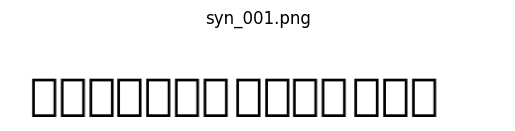

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('synthetic/syn_001.png')
plt.imshow(img)
plt.axis('off')
plt.title('syn_001.png')
plt.show()

In [13]:
!apt-get install -y fonts-noto-core -q
!fc-list | grep -i "noto sans arabic"

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-noto-core
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 12.2 MB of archives.
After this operation, 43.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-core all 20201225-1build1 [12.2 MB]
Fetched 12.2 MB in 0s (44.0 MB/s)
Selecting previously unselected package fonts-noto-core.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-noto-core_20201225-1build1_all.deb ...
Unpacking fonts-noto-core (20201225-1build1) ...
Setting up fonts-noto-core (20201225-1build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts/truetype/noto/NotoSansArabic-Bold.ttf: Noto Sans Arabic:style=Bold
/usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf: Noto Sans Arabic:style=Regular


In [14]:
from PIL import Image, ImageDraw, ImageFont
import arabic_reshaper
from bidi.algorithm import get_display
import os
import csv

urdu_texts = [
    "پاکستان زندہ باد",
    "آج کا موسم خوشگوار ہے",
    "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "محنت کامیابی کی کنجی ہے",
    "پانی زندگی کے لیے ضروری ہے",
    "دوستی ایک انمول رشتہ ہے",
    "کتابیں علم کا خزانہ ہیں",
    "صحت ہزار نعمت ہے",
    "وقت کی قدر کرنی چاہیے",
    "محبت سب سے بڑی طاقت ہے",
    "سچائی ہمیشہ جیتتی ہے",
    "امن ہر انسان کی خواہش ہے",
    "خوشی بانٹنے سے بڑھتی ہے",
    "علم انسان کو روشنی دیتا ہے",
    "قدرت کا حسن بے مثال ہے",
    "اردو ایک شیریں زبان ہے",
    "بچے قوم کا مستقبل ہیں",
    "محنت سے ہر خواب پورا ہوتا ہے",
    "شکر گزاری خوشی کی کنجی ہے",
    "لاہور تاریخی شہر ہے",
    "کتاب دوست بہترین ساتھی ہے",
    "ہمت مرداں مدد خدا",
    "اچھے اخلاق سب سے بڑی دولت ہیں",
]

os.makedirs('synthetic', exist_ok=True)
font = ImageFont.truetype("/usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf", 32)

labels = []
for i, text in enumerate(urdu_texts):
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)

    img = Image.new('RGB', (500, 90), color='white')
    draw = ImageDraw.Draw(img)
    draw.text((20, 25), bidi_text, fill='black', font=font)

    filename = f'syn_{i+1:03d}.png'
    img.save(f'synthetic/{filename}')
    labels.append({'image': filename, 'text': text})

with open('synthetic/labels.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['image', 'text'])
    writer.writeheader()
    writer.writerows(labels)

print(f'Done! {len(labels)} synthetic images regenerated with working Arabic font')

Done! 24 synthetic images regenerated with working Arabic font


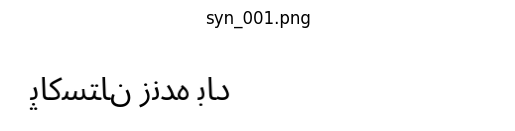

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('synthetic/syn_001.png')
plt.imshow(img)
plt.axis('off')
plt.title('syn_001.png')
plt.show()

In [16]:
import PIL
print(PIL.__version__)

from PIL import features
print('Raqm support (advanced text shaping):', features.check('raqm'))

11.3.0
Raqm support (advanced text shaping): True


In [17]:
from PIL import Image, ImageDraw, ImageFont
import os
import csv

urdu_texts = [
    "پاکستان زندہ باد",
    "آج کا موسم خوشگوار ہے",
    "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "محنت کامیابی کی کنجی ہے",
    "پانی زندگی کے لیے ضروری ہے",
    "دوستی ایک انمول رشتہ ہے",
    "کتابیں علم کا خزانہ ہیں",
    "صحت ہزار نعمت ہے",
    "وقت کی قدر کرنی چاہیے",
    "محبت سب سے بڑی طاقت ہے",
    "سچائی ہمیشہ جیتتی ہے",
    "امن ہر انسان کی خواہش ہے",
    "خوشی بانٹنے سے بڑھتی ہے",
    "علم انسان کو روشنی دیتا ہے",
    "قدرت کا حسن بے مثال ہے",
    "اردو ایک شیریں زبان ہے",
    "بچے قوم کا مستقبل ہیں",
    "محنت سے ہر خواب پورا ہوتا ہے",
    "شکر گزاری خوشی کی کنجی ہے",
    "لاہور تاریخی شہر ہے",
    "کتاب دوست بہترین ساتھی ہے",
    "ہمت مرداں مدد خدا",
    "اچھے اخلاق سب سے بڑی دولت ہیں",
]

os.makedirs('synthetic', exist_ok=True)
font = ImageFont.truetype("/usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf", 32)

labels = []
for i, text in enumerate(urdu_texts):
    img = Image.new('RGB', (500, 90), color='white')
    draw = ImageDraw.Draw(img)
    # direction='rtl' + right anchor lets Pillow's Raqm engine handle Arabic shaping correctly
    draw.text((480, 45), text, fill='black', font=font, anchor='rm', direction='rtl')

    filename = f'syn_{i+1:03d}.png'
    img.save(f'synthetic/{filename}')
    labels.append({'image': filename, 'text': text})

with open('synthetic/labels.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['image', 'text'])
    writer.writeheader()
    writer.writerows(labels)

print(f'Done! {len(labels)} synthetic images regenerated correctly')

Done! 24 synthetic images regenerated correctly


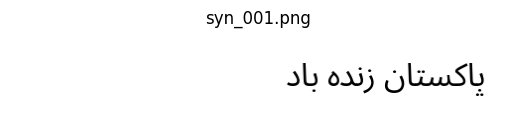

In [18]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('synthetic/syn_001.png')
plt.imshow(img)
plt.axis('off')
plt.title('syn_001.png')
plt.show()

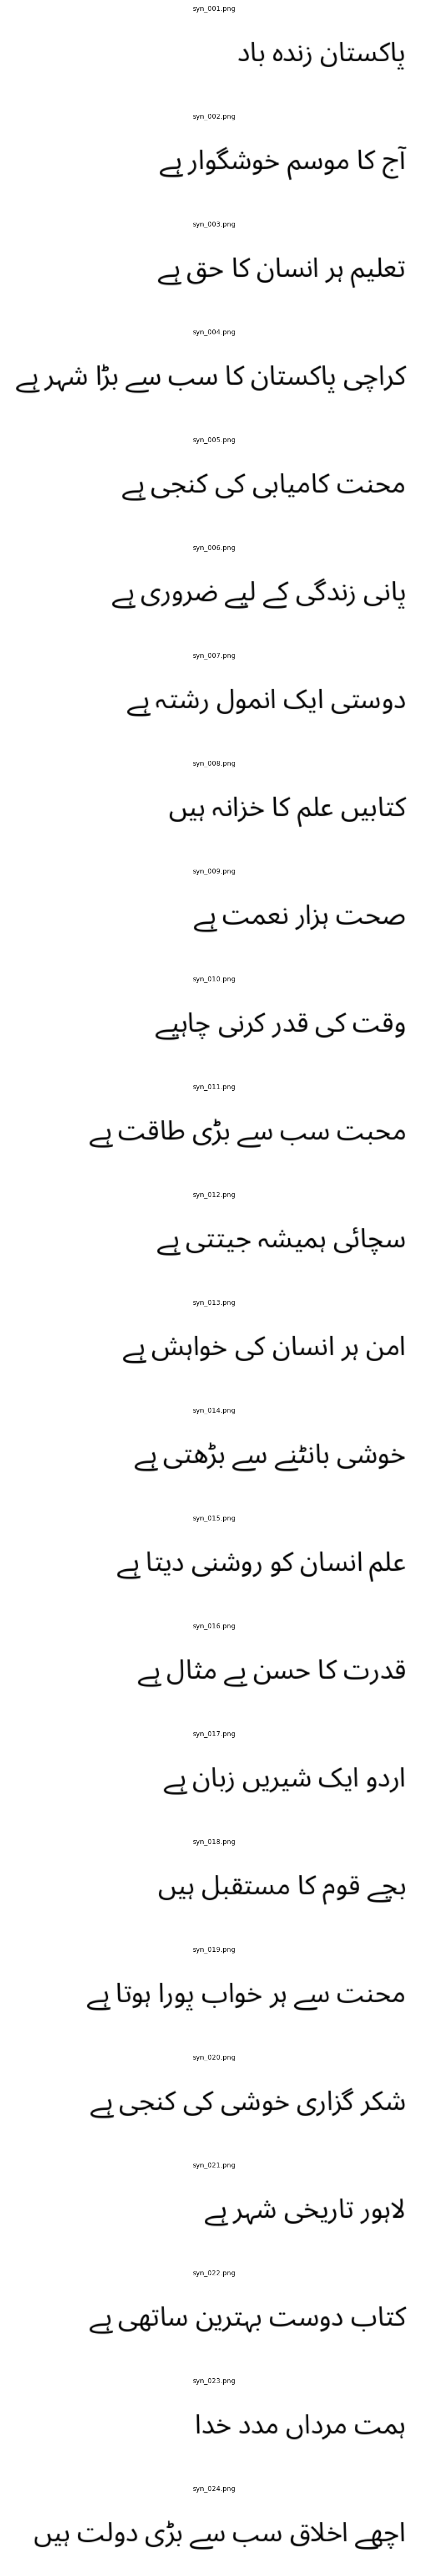

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(24, 1, figsize=(8, 48))

for i in range(24):
    img = Image.open(f'synthetic/syn_{i+1:03d}.png')
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'syn_{i+1:03d}.png', fontsize=9)

plt.tight_layout()
plt.show()

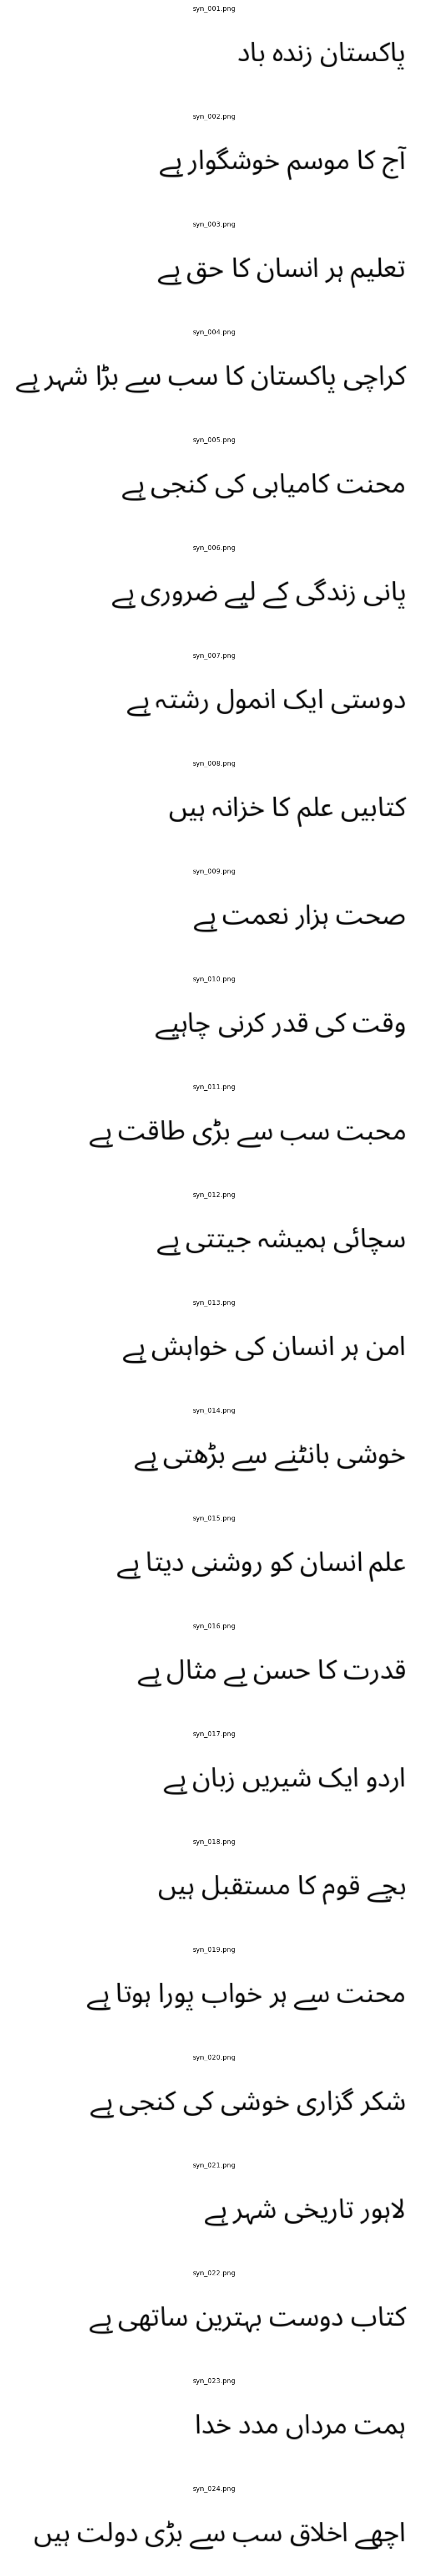

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(24, 1, figsize=(8, 48))
for i in range(24):
    img = Image.open(f'synthetic/syn_{i+1:03d}.png')
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'syn_{i+1:03d}.png', fontsize=9)
plt.tight_layout()
plt.show()

In [21]:
import os
import shutil
import csv
import pandas as pd

final_folder = 'urdu_ocr_dataset'

# Remove old broken version first
if os.path.exists(final_folder):
    shutil.rmtree(final_folder)
os.makedirs(f'{final_folder}/images', exist_ok=True)

master_labels = []
counter = 1

# ---- 1. Synthetic images (24, corrected) ----
for i, text in enumerate(urdu_texts):
    src = f'synthetic/syn_{i+1:03d}.png'
    new_name = f'img_{counter:03d}.png'
    shutil.copy(src, f'{final_folder}/images/{new_name}')
    master_labels.append({'image': new_name, 'text': text, 'source': 'synthetic'})
    counter += 1

# ---- 2. Line_data_newforms (78, labeled via CSV) ----
base2 = '/content/drive/MyDrive/archive/Line_data_newforms'
df2 = pd.read_csv(os.path.join(base2, 'New_data_labels.csv'))
for _, row in df2.iterrows():
    src = os.path.join(base2, 'Images', row['path'])
    new_name = f'img_{counter:03d}.png'
    shutil.copy(src, f'{final_folder}/images/{new_name}')
    master_labels.append({'image': new_name, 'text': row['Labels'], 'source': 'line_data_dataset'})
    counter += 1

# ---- 3. Newspaper screenshots (12, with your real transcribed text) ----
newspaper_texts = [
    # paste your 12 real transcriptions here again, BBC01 → dawn06 order
]

base3 = '/content/drive/MyDrive/archive/newspaper'
newspaper_filenames_sorted = sorted(os.listdir(base3))

for fname, text in zip(newspaper_filenames_sorted, newspaper_texts):
    src = os.path.join(base3, fname)
    new_name = f'img_{counter:03d}.png'
    shutil.copy(src, f'{final_folder}/images/{new_name}')
    master_labels.append({'image': new_name, 'text': text, 'source': 'newspaper_screenshot'})
    counter += 1

with open(f'{final_folder}/labels.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['image', 'text', 'source'])
    writer.writeheader()
    writer.writerows(master_labels)

print(f'Done! {counter-1} images consolidated into {final_folder}/')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/archive/Line_data_newforms/New_data_labels.csv'

In [22]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [23]:
import os

print('Does archive folder exist?', os.path.exists('/content/drive/MyDrive/archive'))
print()
print('Contents of archive:')
print(os.listdir('/content/drive/MyDrive/archive'))
print()
print('Contents of Line_data_newforms:')
print(os.listdir('/content/drive/MyDrive/archive/Line_data_newforms'))

Does archive folder exist? False

Contents of archive:


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/archive'

In [24]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Urdu_OCR']


In [25]:
import os
print(os.listdir('/content/drive/MyDrive/Urdu_OCR'))

['NotoNastaliqUrdu.ttf']


In [26]:
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [27]:
from google.colab import drive
import os

# Ensure the mount point is empty before mounting
if os.path.exists('/content/drive') and os.path.isdir('/content/drive'):
    # Only remove contents if it's a directory, to avoid issues if it's a symlink or file
    if not os.path.islink('/content/drive'): # Check if it's not a symlink to avoid deleting other drives
        for item in os.listdir('/content/drive'):
            item_path = os.path.join('/content/drive', item)
            if os.path.isfile(item_path) or os.path.islink(item_path):
                os.remove(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)

drive.mount('/content/drive', force_remount=True)

ValueError: Mountpoint must not already contain files

In [1]:
!pip install Pillow arabic-reshaper python-bidi -q
!apt-get install -y fonts-noto-core -q

Reading package lists...
Building dependency tree...
Reading state information...
fonts-noto-core is already the newest version (20201225-1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [3]:
import os
print(os.listdir('/content/drive'))

['MyDrive']


In [4]:
import shutil
shutil.rmtree('/content/drive', ignore_errors=True)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Order__05_01_2021_2006_21_04.409.pdf', '9C0BA936-9BDE-4957-AE83-4C0745DC6FEB.jpeg', 'engPRESENTATION-GROUP-3 (6).pdf', '9C0BA936-9BDE-4957-AE83-4C0745DC6FEB.JPG', 'Pic 2', 'Thq.pdf', 'IMG_9642 2 (1).png', 'IMG_9642 2.png', 'IMG_7405.jpg', 'IMG_7405 2.jpg', 'file', 'Colab Notebooks', 'IMG_3730.png', 'Cv.PNG', 'Cv.pdf', 'IMG_9710.jpeg', 'IMG_9717.jpeg', '92c230b4-294b-4ef6-a490-7792e3ae5276.jpeg', 'Classroom', 'urdu text', 'data.zip', 'archive']


In [6]:
import os

archive_path = '/content/drive/MyDrive/archive'
print('Archive contents:', os.listdir(archive_path))

for folder in ['newspaper', 'Line_data_newforms']:
    path = os.path.join(archive_path, folder)
    print(f'\n{folder}:', os.listdir(path))

Archive contents: ['newspaper', 'Line_data_newforms']

newspaper: ['dawn06 (1).png', 'BBC06 (1).png', 'BBC02 (1).png', 'dawn04 (1).png', 'BBC05 (1).png', 'dawn01 (1).png', 'dawn03 (1).png', 'BBC03 (1).png', 'BBC01 (1).png', 'BBC04 (1).png', 'dawn05 (1).png', 'dawn02 (1).png']

Line_data_newforms: ['New_data_labels.csv', 'Images']


In [7]:
from PIL import Image, ImageDraw, ImageFont
import os
import csv

urdu_texts = [
    "پاکستان زندہ باد",
    "آج کا موسم خوشگوار ہے",
    "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "محنت کامیابی کی کنجی ہے",
    "پانی زندگی کے لیے ضروری ہے",
    "دوستی ایک انمول رشتہ ہے",
    "کتابیں علم کا خزانہ ہیں",
    "صحت ہزار نعمت ہے",
    "وقت کی قدر کرنی چاہیے",
    "محبت سب سے بڑی طاقت ہے",
    "سچائی ہمیشہ جیتتی ہے",
    "امن ہر انسان کی خواہش ہے",
    "خوشی بانٹنے سے بڑھتی ہے",
    "علم انسان کو روشنی دیتا ہے",
    "قدرت کا حسن بے مثال ہے",
    "اردو ایک شیریں زبان ہے",
    "بچے قوم کا مستقبل ہیں",
    "محنت سے ہر خواب پورا ہوتا ہے",
    "شکر گزاری خوشی کی کنجی ہے",
    "لاہور تاریخی شہر ہے",
    "کتاب دوست بہترین ساتھی ہے",
    "ہمت مرداں مدد خدا",
    "اچھے اخلاق سب سے بڑی دولت ہیں",
]

os.makedirs('synthetic', exist_ok=True)
font = ImageFont.truetype("/usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf", 32)

labels = []
for i, text in enumerate(urdu_texts):
    img = Image.new('RGB', (500, 90), color='white')
    draw = ImageDraw.Draw(img)
    draw.text((480, 45), text, fill='black', font=font, anchor='rm', direction='rtl')
    filename = f'syn_{i+1:03d}.png'
    img.save(f'synthetic/{filename}')
    labels.append({'image': filename, 'text': text})

with open('synthetic/labels.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['image', 'text'])
    writer.writeheader()
    writer.writerows(labels)

print(f'Done! {len(labels)} synthetic images generated')

Done! 24 synthetic images generated


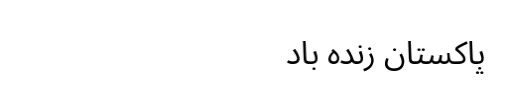

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('synthetic/syn_001.png')
plt.imshow(img)
plt.axis('off')
plt.show()

In [9]:
import os
import shutil
import csv
import pandas as pd

final_folder = 'urdu_ocr_dataset'
if os.path.exists(final_folder):
    shutil.rmtree(final_folder)
os.makedirs(f'{final_folder}/images', exist_ok=True)

master_labels = []
counter = 1

# ---- 1. Synthetic images (24) ----
for i, text in enumerate(urdu_texts):
    src = f'synthetic/syn_{i+1:03d}.png'
    new_name = f'img_{counter:03d}.png'
    shutil.copy(src, f'{final_folder}/images/{new_name}')
    master_labels.append({'image': new_name, 'text': text, 'source': 'synthetic'})
    counter += 1

# ---- 2. Line_data_newforms (78) ----
base2 = '/content/drive/MyDrive/archive/Line_data_newforms'
df2 = pd.read_csv(os.path.join(base2, 'New_data_labels.csv'))
for _, row in df2.iterrows():
    src = os.path.join(base2, 'Images', row['path'])
    new_name = f'img_{counter:03d}.png'
    shutil.copy(src, f'{final_folder}/images/{new_name}')
    master_labels.append({'image': new_name, 'text': row['Labels'], 'source': 'line_data_dataset'})
    counter += 1

# ---- 3. Newspaper screenshots (12, real transcriptions) ----
newspaper_texts = [
    # BBC01
    """وینزویلا میں پانچ روز قبل یکے بعد دیگرے آنے والے شدید زلزلوں میں مرنے والوں کی تعداد 1400 سے بڑھ گئی ہے وہیں ملبے تلے دبے افراد کے زندہ بچنے کی امید دم توڑنے لگی ہے اور ہلاک شدگان کی تعداد میں بڑے اضافے کا خدشہ ظاہر کیا جا رہا ہے۔
بدھ کو ملک کے شمالی حصے میں آنے والے ان زلزلوں سے دارالحکومت کراکس سمیت بڑے علاقے میں عمارتیں تباہ ہوئیں جن کے ملبے تلے دبے افراد کی تلاش کا عمل جاری ہے۔ اتوار کو ملبے سے 33 افراد کو زندہ نکالا گیا۔
ایک برطانوی ریسکیو اہلکار کے مطابق ایسے حالات میں متاثرین کے زندہ نکلنے کی مدت 96 گھنٹے تک سمجھی جاتی ہے جو اتوار کی شام ختم ہو گئی اور اب امدادی کارکنوں کو 'معجزات' کی امید ہے۔
تلاش اور بچاؤ کے عمل میں حصہ لینے کے لیے غیر ملکی ٹیموں کی وینزویلا آمد کا سلسلہ بھی جاری ہے۔ ایک اعلیٰ سرکاری عہدیدار نے بتایا کہ سینکڑوں بین الاقوامی امدادی کارکن وینزویلا پہنچ چکے ہیں جبکہ مزید کی آمد متوقع ہے تاہم ملبہ اٹھانے کے لیے درکار مشینری کی قلت ایک بڑا مسئلہ بن کر سامنے آئی ہے۔""",

    # BBC02
    """تلاش اور بچاؤ کے عمل میں حصہ لینے کے لیے غیر ملکی ٹیموں کی وینزویلا آمد کا سلسلہ بھی جاری ہے۔ ایک اعلیٰ سرکاری عہدیدار نے بتایا کہ سینکڑوں بین الاقوامی امدادی کارکن وینزویلا پہنچ چکے ہیں جبکہ مزید کی آمد متوقع ہے تاہم ملبہ اٹھانے کے لیے درکار مشینری کی قلت ایک بڑا مسئلہ بن کر سامنے آئی ہے۔
حکام کا کہنا ہے کہ اس قدرتی آفت کے نتیجے میں چار ہزار سے زیادہ افراد زخمی بھی ہوئے ہیں۔ وینزویلا میں حکومت کی جانب سے تاحال لاپتہ افراد کی تعداد کے بارے میں معلومات فراہم نہیں کی گئیں تاہم زلزلے کے بعد لاپتہ ہونے والے افراد کے بارے میں معلومات جمع کرنے والی ایک نجی ویب سائٹ کے مطابق 46 ہزار افراد ایسے ہیں جن کا زلزلے کے بعد اپنے اہلخانہ سے رابطہ نہیں ہوا ہے۔""",

    # BBC03
    """کراکس میں موجود بی بی سی کی یوگیتا لمائے کے مطابق ہسپتالوں کی بیرونی دیواریں لاپتہ افراد کی تصاویر سے بھرتی جا رہی ہیں۔
زلزلوں کے فوراً بعد امریکی ارضیاتی سروے نے زلزلے کی شدت اور متاثرہ علاقے کی آبادی کے حساب سے اندازہ لگایا تھا کہ مرنے والوں کی تعداد دس ہزار سے ایک لاکھ کے درمیان ہو سکتی ہے۔
امریکی ارضیاتی سروے (یو ایس جی ایس) کے مطابق بدھ کے روز آنے والے پہلے زلزلے کی شدت 7.2 تھی اور اس کے چند ہی سیکنڈ بعد اس سے بھی زیادہ طاقتور 7.5 شدت کا دوسرا زلزلہ آیا۔""",

    # BBC04
    """لاگوائیرا میں ناتاشا دیاز نے بی بی سی کو بتایا کہ ان کی دو بیٹیاں، جن کی عمریں 22 اور 23 برس ہیں، ایک منہدم شاپنگ سینٹر کے ملبے تلے دبی ہوئی ہیں۔ وہ دونوں وہاں کام کرتی تھیں۔
انہوں نے بتایا کہ 'وہ اپنے دوستوں کے ساتھ تھیں۔ میں صرف یہ چاہتی ہوں کہ وہ مل جائیں۔ مجھے یقین اور امید ہے کہ وہ وہیں ہیں۔'
'میں صرف انہیں واپس اپنے پاس دیکھنا چاہتی ہوں۔ وہ ہی میرا سب کچھ ہیں۔'
قائم مقام صدر ڈیلسی روڈریگز نے جمعے کو ایک ٹی وی بریفنگ میں کہا کہ درجنوں افراد کو زندہ نکال لیا گیا، جو 'ہمارے لیے باعثِ خوشی ہے کہ وہ اپنے خاندان اور پیاروں سے دوبارہ مل سکے۔'
انہوں نے مزید بتایا کہ ابتدائی زلزلوں کے بعد سے 214 آفٹر شاکس آ چکے ہیں۔""",

    # BBC05
    """امدادی کارروائیوں میں مدد کے لیے کئی ممالک نے تعاون کی پیشکش کی ہے، جن میں امریکہ کی جانب سے 15 کروڑ ڈالر کی امداد کا اعلان بھی شامل ہے۔
ہورخے روڈریگز کے مطابق 250 عمارتیں مکمل طور پر تباہ ہو گئی ہیں یا انھیں شدید نقصان پہنچا۔ ان میں سے بیشتر عمارتیں لاگوائیرا میں واقع تھیں جہاں بی بی سی نے ایک 10 منزلہ ہوٹل کے ملبے میں تبدیل ہونے کی ویڈیو کی تصدیق کی۔
وزیر داخلہ دیوسدادو کابیلو کا کہنا ہے کہ دارالحکومت کراکس میں بھی کئی عمارتیں منہدم ہوئی ہیں جبکہ تروخیلو، یاراکوئے، کارابوبو، اراگوا اور میرانڈا کی ریاستیں بھی زلزلے سے متاثر ہوئی ہیں۔""",

    # BBC06
    """اس وقت ایران کا کوئی اعلیٰ سطحی نمائندہ دوحہ میں موجود نہیں: قطر
قطر کا کہنا ہے کہ ڈونلڈ ٹرمپ کے اعلیٰ سطحی نمائندے دوحہ میں موجود ہیں لیکن ایران اور امریکہ کے درمیان کسی اعلیٰ سطح کی ملاقات کی منصوبہ بندی نہیں کی گئی ہے۔
قطر کی وزارتِ خارجہ کے ترجمان ماجد انصاری نے کہا کہ سٹیو وٹکف اور جیرڈ کشنر ثالثوں سے ملاقاتات اور 'علاقائی امور' پر بات چیت کے لیے دوحہ آئے ہیں۔
انہوں نے کہا کہ یہ بات چیت ایران اور دیگر موضوعات جیسے لبنان کی صورتحال کے بارے میں ہوگی۔
انصاری کے مطابق، فی الحال ایران کا کوئی اعلیٰ سطحی نمائندہ قطر میں موجود نہیں ہے اور انہوں نے زور دے کر کہا کہ ڈونلڈ ٹرمپ کے نمائندے ایران کے ساتھ مذاکرات کے لیے دوحہ نہیں آئے ہیں: 'جہاں تک مجھے علم ہے، آنے والے دنوں میں دونوں فریقوں کے درمیان کسی براہِ راست اجلاس کی منصوبہ بندی نہیں کی گئی ہے۔""",

    # dawn01
    """لاہور: قانون نافذ کرنے والے ادارے تقریباً تین ماہ گزرنے کے باوجود تحریک لبیک پاکستان کے سربراہ سعد حسین رضوی اور ان کے بھائی انس رضوی کے ٹھکانے کے بارے میں لاعلم ہیں۔""",

    # dawn02
    """ڈان اخبار میں شائع خبر کے مطابق یہ معاملہ چند روز قبل اس وقت دوبارہ سامنے آیا جب کالعدم مذہبی تنظیم سے منسوب ایک مبینہ بیان سوشل میڈیا پر گردش کرنے لگا، جس میں دعویٰ کیا گیا کہ دونوں بھائی ریاستی اداروں کی تحویل میں ہیں۔""",

    # dawn03
    """تاہم قانون نافذ کرنے والے سینئر حکام اپنے پہلے مؤقف پر قائم ہیں اور ان کا کہنا ہے کہ دونوں بھائی آزاد جموں و کشمیر میں کہیں چھپے ہوئے ہیں۔ ان کے مطابق رضوی برادران اس دن فرار ہوئے جب پنجاب پولیس نے مریدکے میں جی ٹی روڈ پر قائم ٹی ایل پی کے احتجاجی کیمپ کو ختم کرنے کے لیے علی الصبح آپریشن کیا تھا۔""",

    # dawn04
    """ایک سینئر افسر نے ڈان سے بات کرتے ہوئے کہا کہ وہ یقین سے کہہ سکتے ہیں کہ سعد اور انس کسی بھی سیکیورٹی ادارے کی تحویل میں نہیں اور تاحال آزاد کشمیر میں موجود ہیں۔""",

    # dawn05
    """ان کے بقول غالب امکان ہے کہ وہ کالعدم تنظیم کے کسی وفادار کارکن کے پاس پہاڑی علاقوں میں پناہ لیے ہوئے ہیں۔ انہوں نے مبینہ ٹی ایل پی بیان کو جھوٹا، مضحکہ خیز اور خود ساختہ قرار دیا۔""",

    # dawn06
    """امریکی صدر ڈونلڈ ٹرمپ نے کہا ہے کہ ایران کی قیادت نے فوجی کارروائی کی دھمکیوں کے بعد مذاکرات کے لیے رابطہ کیا ہے۔
ایئر فورس ون میں اتوار کو صحافیوں سے گفتگو کرتے ہوئے ڈونلڈ ٹرمپ نے بتایا کہ ایران کے رہنماؤں نے گزشتہ روز فون کیا اور ایک ملاقات طے کی جا رہی ہے۔ ان کے مطابق ایران مذاکرات چاہتا ہے تاہم انہوں نے خبردار کیا کہ ممکن ہے ملاقات سے پہلے ہی ہمیں کارروائی کرنا پڑے۔""",
]

base3 = '/content/drive/MyDrive/archive/newspaper'
newspaper_filenames_sorted = sorted(os.listdir(base3))  # BBC01→BBC06, dawn01→dawn06

assert len(newspaper_filenames_sorted) == len(newspaper_texts), \
    f"Mismatch: {len(newspaper_filenames_sorted)} files vs {len(newspaper_texts)} texts"

for fname, text in zip(newspaper_filenames_sorted, newspaper_texts):
    src = os.path.join(base3, fname)
    new_name = f'img_{counter:03d}.png'
    shutil.copy(src, f'{final_folder}/images/{new_name}')
    master_labels.append({'image': new_name, 'text': text, 'source': 'newspaper_screenshot'})
    counter += 1

with open(f'{final_folder}/labels.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['image', 'text', 'source'])
    writer.writeheader()
    writer.writerows(master_labels)

print(f'Done! {counter-1} images consolidated into {final_folder}/')
print(f'Breakdown: 24 synthetic + 78 line_data + 12 newspaper = {counter-1}')

Done! 114 images consolidated into urdu_ocr_dataset/
Breakdown: 24 synthetic + 78 line_data + 12 newspaper = 114


In [10]:
import pandas as pd

df = pd.read_csv('urdu_ocr_dataset/labels.csv')
print('Total rows:', len(df))
print('Blank text entries:', df['text'].isna().sum() + (df['text'] == '').sum())
print()
print(df['source'].value_counts())

Total rows: 114
Blank text entries: 0

source
line_data_dataset       78
synthetic               24
newspaper_screenshot    12
Name: count, dtype: int64


In [12]:
import shutil

shutil.make_archive('urdu_ocr_dataset', 'zip', 'urdu_ocr_dataset')
shutil.copy('urdu_ocr_dataset.zip', '/content/drive/MyDrive/Urdu_OCR/urdu_ocr_dataset.zip')

print('Saved to Drive: MyDrive/Urdu_OCR/urdu_ocr_dataset.zip')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Urdu_OCR/urdu_ocr_dataset.zip'

In [13]:
import os

# Check if Drive is still mounted
print('Drive mounted:', os.path.exists('/content/drive/MyDrive'))

# Check if Urdu_OCR folder exists
print('Urdu_OCR exists:', os.path.exists('/content/drive/MyDrive/Urdu_OCR'))

Drive mounted: True
Urdu_OCR exists: False


In [14]:
import os
os.makedirs('/content/drive/MyDrive/Urdu_OCR', exist_ok=True)
print('Folder created')

Folder created


In [15]:
import shutil
shutil.copy('urdu_ocr_dataset.zip', '/content/drive/MyDrive/Urdu_OCR/urdu_ocr_dataset.zip')
print('Saved to Drive: MyDrive/Urdu_OCR/urdu_ocr_dataset.zip')

Saved to Drive: MyDrive/Urdu_OCR/urdu_ocr_dataset.zip


Finally after a lot of hardwork

In [16]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.unpack_archive('/content/drive/MyDrive/Urdu_OCR/urdu_ocr_dataset.zip', 'urdu_ocr_dataset')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
from google.colab import files
files.download('urdu_ocr_dataset.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Make folders /(forget)

In [19]:
import os
import shutil
import pandas as pd

# Load current dataset
df = pd.read_csv('urdu_ocr_dataset/labels.csv')

# Create organized subfolders
base = 'urdu_ocr_dataset'
folders = {
    'synthetic': f'{base}/images/synthetic',
    'line_data_dataset': f'{base}/images/handwritten',
    'newspaper_screenshot': f'{base}/images/newspaper',
}

for folder in folders.values():
    os.makedirs(folder, exist_ok=True)

# Move each image into its matching subfolder, update the CSV path
new_paths = []
for _, row in df.iterrows():
    old_path = f'{base}/images/{row["image"]}'
    target_folder = folders[row['source']]
    new_path = f'{target_folder}/{row["image"]}'
    shutil.move(old_path, new_path)
    # Store the relative path (e.g. 'synthetic/img_001.png') for the CSV
    rel_path = os.path.relpath(new_path, base)
    new_paths.append(rel_path)

df['image'] = new_paths
df.to_csv(f'{base}/labels.csv', index=False)

print('Done! Images organized into subfolders:')
print(f"  synthetic/    -> {(df['source']=='synthetic').sum()} images")
print(f"  handwritten/  -> {(df['source']=='line_data_dataset').sum()} images")
print(f"  newspaper/    -> {(df['source']=='newspaper_screenshot').sum()} images")

Done! Images organized into subfolders:
  synthetic/    -> 24 images
  handwritten/  -> 78 images
  newspaper/    -> 12 images


In [20]:
import shutil

shutil.make_archive('urdu_ocr_dataset', 'zip', 'urdu_ocr_dataset')
shutil.copy('urdu_ocr_dataset.zip', '/content/drive/MyDrive/Urdu_OCR/urdu_ocr_dataset.zip')
print('Updated dataset (organized) saved to Drive')

Updated dataset (organized) saved to Drive


In [21]:
from google.colab import files
files.download('urdu_ocr_dataset.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile

zip_path = '/content/drive/MyDrive/Urdu_OCR/urdu_ocr_dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    names = z.namelist()
    handwritten_files = [n for n in names if 'handwritten' in n.lower() and n.lower().endswith('.png')]
    synthetic_files = [n for n in names if 'synthetic' in n.lower() and n.lower().endswith('.png')]
    newspaper_files = [n for n in names if 'newspaper' in n.lower() and n.lower().endswith('.png')]

    print('Total files in zip:', len(names))
    print('Handwritten images:', len(handwritten_files))
    print('Synthetic images:', len(synthetic_files))
    print('Newspaper images:', len(newspaper_files))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total files in zip: 119
Handwritten images: 78
Synthetic images: 24
Newspaper images: 12


In [23]:
import os

laptop_folder = 'urdu_ocr_dataset/images/handwritten'  # adjust if your local path differs
# But since we can't access your laptop from Colab, instead let's generate
# the expected filename list for you to compare against

expected = [f'img_{i:03d}.png' for i in range(25, 103)]  # 025 to 102
print('Expected filenames (78 total):')
print(expected)

Expected filenames (78 total):
['img_025.png', 'img_026.png', 'img_027.png', 'img_028.png', 'img_029.png', 'img_030.png', 'img_031.png', 'img_032.png', 'img_033.png', 'img_034.png', 'img_035.png', 'img_036.png', 'img_037.png', 'img_038.png', 'img_039.png', 'img_040.png', 'img_041.png', 'img_042.png', 'img_043.png', 'img_044.png', 'img_045.png', 'img_046.png', 'img_047.png', 'img_048.png', 'img_049.png', 'img_050.png', 'img_051.png', 'img_052.png', 'img_053.png', 'img_054.png', 'img_055.png', 'img_056.png', 'img_057.png', 'img_058.png', 'img_059.png', 'img_060.png', 'img_061.png', 'img_062.png', 'img_063.png', 'img_064.png', 'img_065.png', 'img_066.png', 'img_067.png', 'img_068.png', 'img_069.png', 'img_070.png', 'img_071.png', 'img_072.png', 'img_073.png', 'img_074.png', 'img_075.png', 'img_076.png', 'img_077.png', 'img_078.png', 'img_079.png', 'img_080.png', 'img_081.png', 'img_082.png', 'img_083.png', 'img_084.png', 'img_085.png', 'img_086.png', 'img_087.png', 'img_088.png', 'img_089